# mjo_phase_background

- Plot background for MJO phase-space diagrams
- [NCL: mjo_phase_background](https://www.ncl.ucar.edu/Document/Functions/Diagnostics/mjo_phase_background.shtml)

[NCL OUTPUT](mjo_phase_background.ncl) with different radii:
<table>
  <tr>
    <td><img src="mjo_output/mjo_phase_background_radius_1.png" width="500" height="300" /></td>
    <td><img src="mjo_output/mjo_phase_background_radius_3.png" width="500" height="300" /></td>
  </tr>
</table>

In [56]:
# Create base of the map for a Phase Diagram
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker # force integar ticks on axis
import matplotlib.lines as lines # add phase division lines
import numpy as np

def mjo_phase_background(is_darkmode=False, start_date="Start", end_date="End", radius=1):
    if is_darkmode:
        plt.style.use("dark_background") # dark mode for testing
        color_dm = "white"
    else:
        plt.style.use("default")
        color_dm = "black"
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)
    
    # set x and y axis labels
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax2 = ax.twinx() 
    ax3 = ax.twiny()
    ax2.set_xlim(-4, 4)
    ax2.set_ylim(-4, 4)
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-4, 4)
    ax.set_xlabel("Bottom - Phase 2 (Indian Ocean) Phase 3", fontsize=20, labelpad=20)
    ax.set_ylabel("Left - Phase 1 (Western Hemisphere, Africa) Phase 8", fontsize=20, labelpad=20)
    ax2.set_ylabel("Right - Phase 5 (Maritime) Phase 4", fontsize=20, labelpad=40, rotation=270)
    ax3.set_xlabel("Top - Phase 7 (Western Pacific) Phase 6", fontsize=20, labelpad=20)
    
    # add amplitude circle
    amplitude_circle = plt.Circle((0, 0), radius, color=color_dm, fill=False)
    ax.add_patch(amplitude_circle)
    
    # add phase diagram lines
    ## Phase 1-8
    phase_line = lines.Line2D([-4, -radius],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 1-2
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 2-3
    phase_line = lines.Line2D([0, 0],
                               [-radius, -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 3-4
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 4-5
    phase_line = lines.Line2D([radius, 4],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 5-6
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 6-7
    phase_line = lines.Line2D([0, 0],
                               [radius, 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 7-8
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    
    # add tick marks
    full_tickmarks = np.arange(-4, 4.5, 0.5)
    ax.set_xticks(full_tickmarks)
    ax.set_yticks(full_tickmarks)
    # hide tickmarks for top/right axis)
    ax2.set_yticks(full_tickmarks)
    ax3.set_xticks(full_tickmarks)
    
    # add (optional) phase number text in each segment
    ax.text(-3, -1.5, "1", color=color_dm, fontsize=20)
    ax.text(-1.5, -3, "2", color=color_dm, fontsize=20)
    ax.text(1.5, -3, "3", color=color_dm, fontsize=20)
    ax.text(3, -1.5, "4", color=color_dm, fontsize=20)
    ax.text(3, 1.5, "5", color=color_dm, fontsize=20)
    ax.text(1.5, 3, "6", color=color_dm, fontsize=20)
    ax.text(-1.5, 3, "7", color=color_dm, fontsize=20)
    ax.text(-3, 1.5, "8", color=color_dm, fontsize=20)
    
    # plot whole numbers integar tick marks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    # increase length of major ticks
    ax.tick_params(which="major", length=10)
    ax2.tick_params(which="major", length=10)
    ax3.tick_params(which="major", length=10)

    # plot minor ticks every 0.25
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    # increase length of minor ticks
    ax.tick_params(which="minor", length=5)
    ax2.tick_params(which="minor", length=5)
    ax3.tick_params(which="minor", length=5)

    # plot with title
    plt.title(f"MJO Phase: 15S-15N: {start_date}-{end_date}", fontsize=30, fontweight="bold", pad=20)
    
    plt.show()

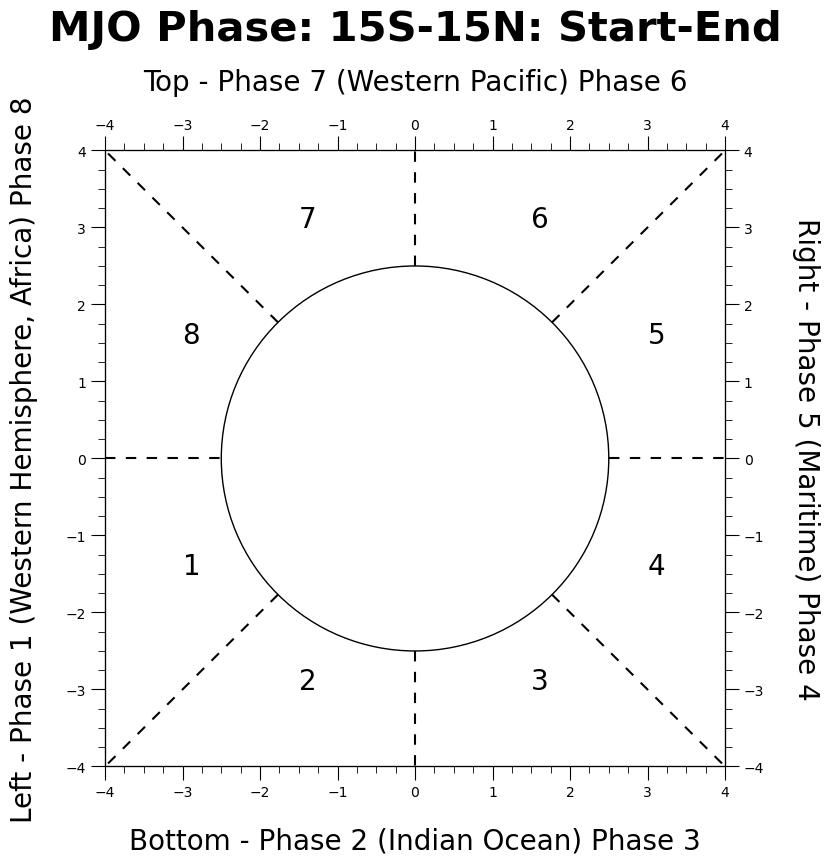

In [62]:
mjo_phase_background(is_darkmode=False, radius=2.5)

Working Example -- Phase diagram split into 8 equal parts for example:

 <p align="center">
    <img src="https://psl.noaa.gov/mjo/mjoindex/romi_cpcolr_phase_diag.png">
</p>

## Wheeler-Hendon MJO Plot
The Wheeler-Hendon MJO index plots the time, location, and magnitude/amplitude of the MJO described by the multivariate MJO index. The amplitude of the index represents the radial distance from the center. Phases are split into 8 standard MJO phases.

- ROMI: Realtime OLR (Outgoing longware radiation) MJO Index
- RMM*: Realtime Multivariate Madden-Julian Index
- OOMI: Original OLR MJO Index
- OMI: OLR (Outgoing longware radiation) MJO Index
- RMII: Realtime Multivariate Index

RMM Index from Principal Component Analysis (PCA) ([see more](https://willychap.github.io/MJOcast/WHprimer.html)) which captures the MJO's signature:
- "Outgoing Longwave Radiation (OLR): A measure of Earth’s thermal radiation emitted to space. Negative OLR anomalies indicate enhanced convection associated with the active phase of the MJO"
- "Zonal Wind at 850mb and 200mb: Zonal wind anomalies at these pressure levels indicate changes in atmospheric circulation due to the MJO. The phase relationship between these winds determines the MJO’s movement"

PCA produces two Principal Components (PC) known as RMM1 and RMM2
- **RMM1: Represents the MJO's amplitude** ("Larger RMM1 values indicate stronger MJO activity. Negative values correspond to the suppressed phase (inactive MJO), and positive values indicate the active phase (enhanced convection and circulation)")
- **RMM2: Represents the MJO's phase** ("The RMM2 phase determines the geographic location of the MJO’s convection center. It’s categorized into eight phases, each linked to specific equatorial regions")

Graph details:
- Each month is indicated by a seperate line color
- The numbers correspond to the day of the month

In [579]:
import pandas as pd

In [625]:
def retrieve_NOAA_data(data_type=None):
    # https://www.psl.noaa.gov/mjo/
    # OMI: https://www.psl.noaa.gov/mjo/mjoindex/omi.1x.txt
    # VPM: https://www.psl.noaa.gov/mjo/mjoindex/vpm.1x.txt
    # ROMI: https://www.psl.noaa.gov/mjo/mjoindex/romi.1x.txt
    url = f"https://www.psl.noaa.gov/mjo/mjoindex/{data_type.lower()}.1x.txt"
    column_names = ["YYYY", "MM", "DD", "HH", "RMM1", "RMM2", "Phase"]
    try:
        df = pd.read_csv(url, sep="\s+", header=None, names=column_names)
        print(f"Retrieving data from: {url}")
        return df
    except:
        print(f"invalid url: {url}")
        return pd.DataFrame(columns=column_names)

In [686]:
# Create base of the map for a Phase Diagram
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker # force integar ticks on axis
import matplotlib.lines as lines # add phase division lines
import numpy as np

def mjo_phase_plot(is_darkmode=False,
                  data=None,
                  radius=1,
                   display_phase_number=True,
                  phase_type=None):
    if is_darkmode:
        plt.style.use("dark_background") # dark mode for testing
        color_dm = "white"
    else:
        plt.style.use("default")
        color_dm = "black"
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111)
    
    # set x and y axis labels
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax2 = ax.twinx() 
    ax3 = ax.twiny()
    ax2.set_xlim(-4, 4)
    ax2.set_ylim(-4, 4)
    ax3.set_xlim(-4, 4)
    ax3.set_ylim(-4, 4)
    ax.set_ylabel("Phase 1 (Western Hemisphere, Africa) Phase 8", fontsize=20, labelpad=20)
    ax.set_xlabel("Phase 2 (Indian Ocean) Phase 3", fontsize=20, labelpad=20)
    ax2.set_ylabel("Phase 5 (Maritime) Phase 4", fontsize=20, labelpad=40, rotation=270)
    ax3.set_xlabel("Phase 7 (Western Pacific) Phase 6", fontsize=20, labelpad=20)
    
    # add amplitude circle
    amplitude_circle = plt.Circle((0, 0), radius, color=color_dm, fill=False)
    ax.add_patch(amplitude_circle)
    
    # add phase diagram lines
    ## Phase 1-8
    phase_line = lines.Line2D([-4, -radius],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 1-2
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 2-3
    phase_line = lines.Line2D([0, 0],
                               [-radius, -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 3-4
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [-radius/np.sqrt(2), -4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 4-5
    phase_line = lines.Line2D([radius, 4],
                               [0, 0],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))

    ax.add_line(phase_line)
    ## Phase 5-6
    phase_line = lines.Line2D([radius/np.sqrt(2), 4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 6-7
    phase_line = lines.Line2D([0, 0],
                               [radius, 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    ## Phase 7-8
    phase_line = lines.Line2D([-radius/np.sqrt(2), -4],
                               [radius/np.sqrt(2), 4],
                               c=color_dm,
                               linestyle="--",
                               dashes=(5, 5))
    ax.add_line(phase_line)
    
    # add tick marks
    full_tickmarks = np.arange(-4, 4.5, 0.5)
    ax.set_xticks(full_tickmarks)
    ax.set_yticks(full_tickmarks)
    # hide tickmarks for top/right axis)
    ax2.set_yticks(full_tickmarks)
    ax3.set_xticks(full_tickmarks)
    
    # add (optional) phase number text in each segment
    if display_phase_number:
        ax.text(-3, -1.5, "1", color=color_dm, fontsize=20)
        ax.text(-1.5, -3, "2", color=color_dm, fontsize=20)
        ax.text(1.5, -3, "3", color=color_dm, fontsize=20)
        ax.text(3, -1.5, "4", color=color_dm, fontsize=20)
        ax.text(3, 1.5, "5", color=color_dm, fontsize=20)
        ax.text(1.5, 3, "6", color=color_dm, fontsize=20)
        ax.text(-1.5, 3, "7", color=color_dm, fontsize=20)
        ax.text(-3, 1.5, "8", color=color_dm, fontsize=20)
    
    # plot whole numbers integar tick marks
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax3.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    # increase length of major ticks
    ax.tick_params(which="major", length=10)
    ax2.tick_params(which="major", length=10)
    ax3.tick_params(which="major", length=10)

    # plot minor ticks every 0.25
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    ax3.xaxis.set_minor_locator(ticker.MultipleLocator(0.25))
    # increase length of minor ticks
    ax.tick_params(which="minor", length=5)
    ax2.tick_params(which="minor", length=5)
    ax3.tick_params(which="minor", length=5)

    # plot with title
    first_index = data.iloc[0]
    start_date = f'{int(first_index["YYYY"])}-{int(first_index["MM"])}-{int(first_index["DD"])}'
    last_index = data.iloc[-1]
    end_date = f'{int(last_index["YYYY"])}-{int(last_index["MM"])}-{int(last_index["DD"])}'
    
    plt.title(f"MJO Phase: {phase_type}: {start_date} to {end_date}", fontsize=30, fontweight="bold", pad=20)
  
    # Setup Months Text at Bottom of Plot
    colors = ["tomato", "dodgerblue", "orange", "green", "magenta", "yellow",
              "pink", "cyan", "gold", "lime", "darkviolet", "olive"]
    
    month_dict = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 
                  7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

    all_months = data["MM"].unique()
    months = [color for month_mm, color in month_dict.items() if month_mm in all_months]
    
    start_index = -3.3 + ((12 - len(months))* 0.28)

    for i, month in enumerate(months):
        if i == 0:
            # First Element
            text = ax.text(start_index, -3.7, month, color=colors[i], fontsize=13)
        else:
            # Remaining Elements
            text = ax.annotate(f"  {month}", 
                               xycoords=text, 
                               xy=(1, 0), 
                               verticalalignment="bottom",
                               fontsize=13,
                               color=colors[i])

        # filter data based on each month
        last_index = data[data["MM"] == all_months[i] ].index[-1]

        # include the first day of the next month in data to preserve continuity 
        next_index = []
        if last_index + 1 in data.index:
            next_index = [last_index + 1]
        filtered_df = data.loc[(data["MM"] == all_months[i]) | (data.index.isin(next_index))]
        x_data = filtered_df["RMM2"]
        y_data = -filtered_df["RMM1"]        
        
        # Plot data
        plt.plot(x_data, y_data, zorder=1, c=colors[i])
        plt.scatter(x_data, y_data, zorder=1, c=colors[i])

        # plot dark mark at the start and end
        if i == 0:
            plt.scatter(x_data.iloc[[0]], y_data.iloc[[0]], c=color_dm, s=150)
        if i+1 == len(months):
            plt.scatter(x_data.iloc[[-1]], y_data.iloc[[-1]], c=color_dm, s=150)

    check_date = 20
    print(data[(data["DD"] == check_date)])
    print("x data =")
    print(data[(data["DD"] == check_date)]["RMM2"].values)
    print("y data =")
    print(-data[(data["DD"] == check_date)]["RMM1"].values)

    # Annotate text every 5 days
    days_text = [5, 10, 15, 20, 25, 30]
    days_filtered = data[data["DD"].isin(days_text)]
    for index, row in days_filtered.iterrows():
        plt.text(x=row["RMM2"],
                y=-row["RMM1"],
                s=int(row["DD"]),
                ha="center",
                zorder=2,
                c=color_dm,
                fontweight="bold")
    plt.show()

Retrieving data from: https://www.psl.noaa.gov/mjo/mjoindex/omi.1x.txt
      YYYY  MM  DD  HH     RMM1     RMM2    Phase
8420  2002   1  20   0  2.89945  0.63636  2.96846
8451  2002   2  20   0 -2.01589  0.24650  2.03091
x data =
[0.63636 0.2465 ]
y data =
[-2.89945  2.01589]


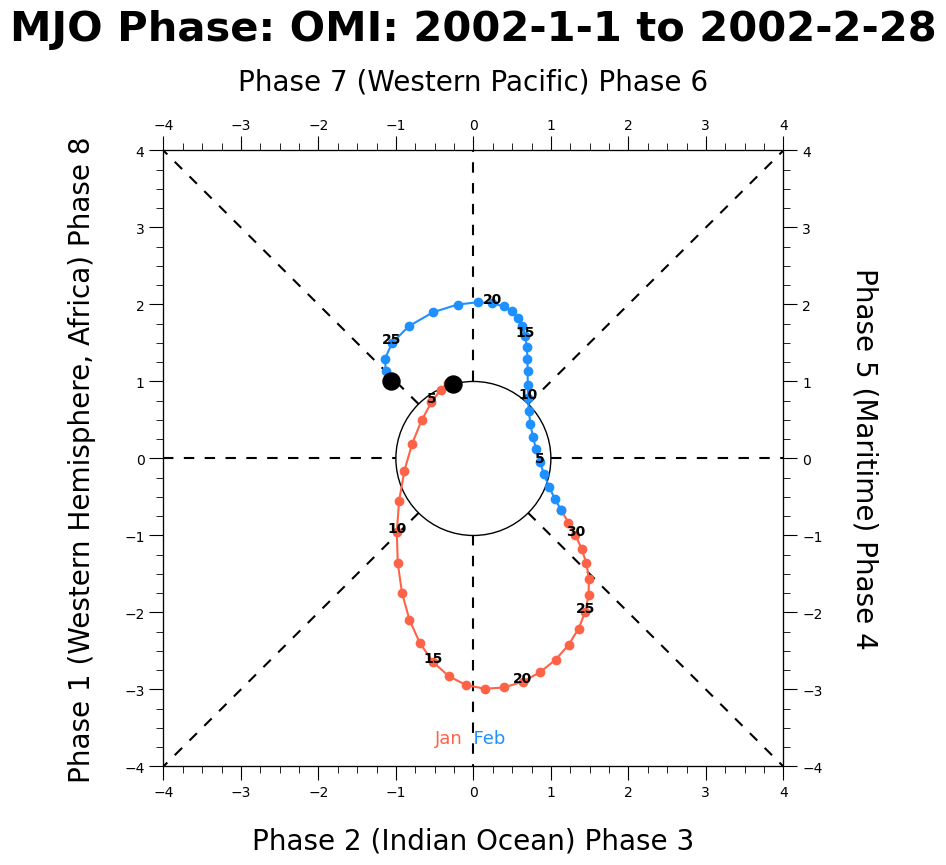

In [687]:
type_of_phase = "OMI"
noaa_df = retrieve_NOAA_data(type_of_phase)

#df_2002 = noaa_df[noaa_df["YYYY"] == 2002]
#df_2002 = noaa_df[(noaa_df["YYYY"] == 2002) & ((noaa_df["MM"] == 1))]
df_2002 = noaa_df[(noaa_df["YYYY"] == 2002) & ((noaa_df["MM"] == 1) | (noaa_df["MM"] == 2))]
#df_2002 = noaa_df[(noaa_df["YYYY"] == 2002) & ((noaa_df["MM"] == 1) | (noaa_df["MM"] == 2) | (noaa_df["MM"] == 3))]

mjo_phase_plot(is_darkmode=False,
               radius=1,
               data=df_2002, 
               phase_type=type_of_phase,
               display_phase_number=False)